# Shallow Transformer Architecture Search for Isoform Prediction

Transformers are promising because they can model gene–gene dependencies, but standard self-attention has O(N²) cost in sequence length (too large for 45,000 genes).
To make transformers feasible, genes are grouped into patches.
Two separate hyperparameter searches were conducted using random search:

### Trial 1 (10 trials):

- aimed at small, low-capacity models
- larger patch sizes (64–256)
- smaller d_model options (64–128)
- run on limited-memory GPU

### Trial 2 (50 trials):
- expanded search space
- smaller patches (16–64)
- larger d_model (128–384)
- more heads (2–8)
-run on a high-memory GPU

The notebook loads and compares results from both searches.

## Model Components
Patch embedding:
1. Linear projection of each patch into a dmodel dimensional token.
2. Positional embeddings:
No biological order exists, but positional embeddings break symmetry.
3. 1–2 Transformer Encoder layers:
Multi-head self-attention + FFN + residuals + LayerNorm.
4. Pooling:
- mean pooling
- attention pooling
5. MLP head:
Produces ~162k isoform outputs.

**All the scripts used for this analysis can be found under the `/ShallowTransformer` directory.** 

## Load Results for Trial 1 (10-Trial Search)

In [ ]:
import json
import pandas as pd


summary_10 = json.load(open("~/DeepIsoQ/ShallowTransformer/ShallowTrans_v1/results_v1/arch_search_summary.json"))
df_10 = pd.read_csv("~/DeepIsoQ/ShallowTransformer/ShallowTrans_v1/results_v1/arch_search_results.csv")

summary_10


{'best': {'name': 'tf_p64_d128_h4_L2_attn_gelu_t7',
  'patch_size': 64,
  'd_model': 128,
  'n_heads': 4,
  'num_layers': 2,
  'pooling': 'attn',
  'activation': 'gelu',
  'dropout': 0.0,
  'lr': 0.002,
  'momentum': '-',
  'step_size': '-',
  'gamma': '-',
  'batch_size': 16,
  'epochs_trained': 120,
  'val_mse': 0.9623922685868701,
  'val_pearson': 0.706958532333374,
  'train_time_sec': 1561.5,
  'test_mse': 0.9729674458503723,
  'test_pearson': 0.7084893584251404},
 'top5': [{'name': 'tf_p64_d128_h4_L2_attn_gelu_t7',
   'patch_size': 64,
   'd_model': 128,
   'n_heads': 4,
   'num_layers': 2,
   'pooling': 'attn',
   'activation': 'gelu',
   'dropout': 0.0,
   'lr': 0.002,
   'momentum': '-',
   'step_size': '-',
   'gamma': '-',
   'batch_size': 16,
   'epochs_trained': 120,
   'val_mse': 0.9623922685868701,
   'val_pearson': 0.706958532333374,
   'train_time_sec': 1561.5,
   'test_mse': 0.9729674458503723,
   'test_pearson': 0.7084893584251404},
  {'name': 'tf_p256_d128_h4_L2_attn

## Load Results for Trial 2 (50-trial search)

In [47]:


summary_50 = json.load(open("ShallowTransformer/ShallowTrans_v3_a100/results50/arch_search_summary.json"))
df_50 = pd.read_csv("ShallowTransformer/ShallowTrans_v3_a100/results50/arch_search_results.csv")

summary_50



{'best': {'name': 'tf_p32_d256_h8_L2_mean_relu_t19',
  'patch_size': 32,
  'd_model': 256,
  'n_heads': 8,
  'num_layers': 2,
  'pooling': 'mean',
  'activation': 'relu',
  'dropout': 0.0,
  'lr': 0.003,
  'momentum': '-',
  'step_size': '-',
  'gamma': '-',
  'batch_size': 64,
  'epochs_trained': 120,
  'val_mse': 0.9196385689881517,
  'val_pearson': 0.7196103930473328,
  'train_time_sec': 965.3,
  'test_mse': 0.9294442534446716,
  'test_pearson': 0.7219229340553284},
 'top5': [{'name': 'tf_p32_d256_h8_L2_mean_relu_t19',
   'patch_size': 32,
   'd_model': 256,
   'n_heads': 8,
   'num_layers': 2,
   'pooling': 'mean',
   'activation': 'relu',
   'dropout': 0.0,
   'lr': 0.003,
   'momentum': '-',
   'step_size': '-',
   'gamma': '-',
   'batch_size': 64,
   'epochs_trained': 120,
   'val_mse': 0.9196385689881517,
   'val_pearson': 0.7196103930473328,
   'train_time_sec': 965.3,
   'test_mse': 0.9294442534446716,
   'test_pearson': 0.7219229340553284},
  {'name': 'tf_p16_d256_h8_L2_mea

## Barplot Summary of the Validation MSE of the top 10 models (combining trial 1 + trial 2)

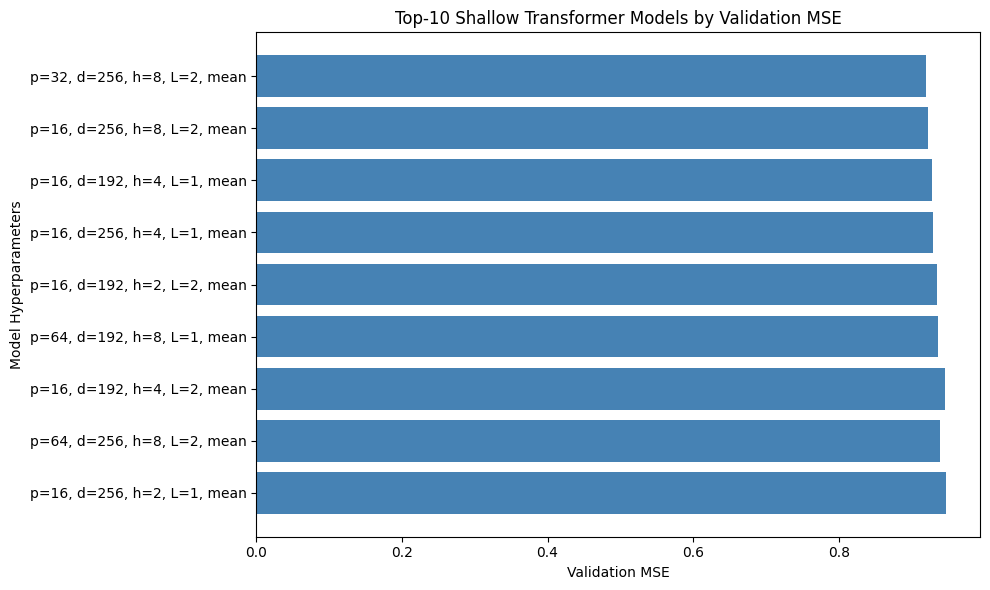

In [48]:
df_all = pd.concat([df_10, df_50], ignore_index=True)

# Sort and take top 10 by val MSE
df_top10 = df_all.sort_values("val_mse").head(10).copy()

# Construct readable labels for each model
df_top10["label"] = (
    "p=" + df_top10["patch_size"].astype(str)
    + ", d=" + df_top10["d_model"].astype(str)
    + ", h=" + df_top10["n_heads"].astype(str)
    + ", L=" + df_top10["num_layers"].astype(str)
    + ", " + df_top10["pooling"]
)

plt.figure(figsize=(10, 6))

plt.barh(df_top10["label"], df_top10["val_mse"], color="steelblue")
plt.xlabel("Validation MSE")
plt.ylabel("Model Hyperparameters")
plt.title("Top-10 Shallow Transformer Models by Validation MSE")

plt.gca().invert_yaxis()  # Best model at top
plt.tight_layout()
plt.show()
